
## Experimental Scenario 3: Differential Privacy 
This scenario introduces **Differential Privacy (DP)** into the learning protocol. The objective is to mathematically guarantee that the participation of a specific patient in the dataset cannot be inferred by observing the updates of the global model.

### The DP Mechanism
For each client, two critical operations are added during local training before sending the gradients:
1. **L2-Norm Clipping:** Gradients are capped by a threshold ($C=1.0$) to limit the maximum influence of any single individual.
2. **Noise Addition:** Gaussian noise, proportional to the $\sigma$ parameter, is injected into the aggregated gradients.

### Noise Levels and Protection
We test three values of the `noise_multiplier` ($\sigma$) to measure the trade-off between utility, fairness, and privacy:

| Parameter ($\sigma$) | Privacy Level | Theoretical Impact | Risk to the Model |
| :--- | :--- | :--- | :--- |
| **0.1** | **Low** | Symbolic protection. Maximum utility. | Low risk of performance degradation. |
| **0.5** | **Standard** | Balanced trade-off used in research. | Appearance of fluctuations in convergence. |
| **1.2** | **High** | Robust protection. | Risk of F1-Score collapse (Signal drowned in noise). |



### Imports / Paths / Utils

In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix

from fluke_package.fluke.data.datasets import Datasets
from fluke_package.fluke.nets import Diabetes_LR, Diabetes_SVM, Diabetes_MLP

# Configuration
BASE_PATH = Path('runs/NOISE')
SIGMAS = ['0.1', '0.5', '1.2']
MODELS = ['LR', 'MLP', 'SVM']
COLORS = {'0.1': '#3498db', '0.5': '#9b59b6', '1.2': '#2c3e50'} # Dégradé de bleu/sombre pour le bruit

data_container = Datasets.DIABETES()

def load_global_metrics(run_path: Path) -> pd.DataFrame:
    global_csv = run_path / 'global_metrics.csv'
    metrics_csv = run_path / 'metrics.csv'
    if global_csv.exists():
        return pd.read_csv(global_csv)
    if metrics_csv.exists():
        return pd.read_csv(metrics_csv)
    raise FileNotFoundError(f'No global metrics CSV in {run_path}')


def load_comm_costs(run_path: Path):
    path = run_path / 'comm_costs.csv'
    return pd.read_csv(path) if path.exists() else None


def load_run_time(run_path: Path):
    path = run_path / 'run_metrics.csv'
    if not path.exists():
        return None
    df = pd.read_csv(path)
    row = df[df['metric'] == 'run_time_seconds']
    if row.empty:
        return None
    return float(row['value'].iloc[0])


cwd = Path.cwd()
print(f"Current working directory: {cwd}")
base = cwd / 'runs'
print(f"Looking for runs in: {base}")


Distribution of target (Diabetes_binary) :
   - No Diabetes ((0,)): 218334 persons (86.07%)
   - No Diabetes ((1,)): 35346 persons (13.93%)
--------------------------------------------------
Sensible variable 'Sex' detected at index : 17

Size of the dataset :
   - Train set : 202944 samples, 21 features
   - Test set  : 50736 samples
--------------------------------------------------
Current working directory: c:\Users\bapti\Documents\INSA\S2\Cours\FL\M1_Federated_learning\project_medical_fl_implementation
Looking for runs in: c:\Users\bapti\Documents\INSA\S2\Cours\FL\M1_Federated_learning\project_medical_fl_implementation\runs


### Utility metrics

[SyntaxWarning] <>:6
invalid escape sequence '\s'
[SyntaxWarning] <>:6
invalid escape sequence '\s'
[SyntaxWarning] C:\Users\bapti\AppData\Local\Temp\ipykernel_2636\3391905524.py:6
invalid escape sequence '\s'


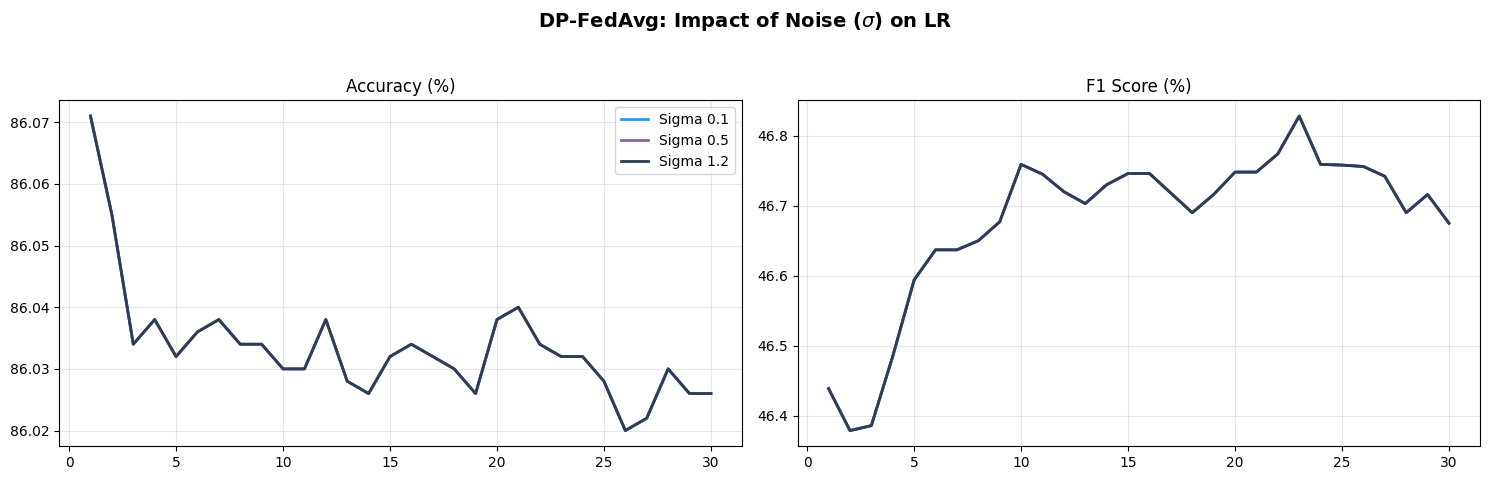

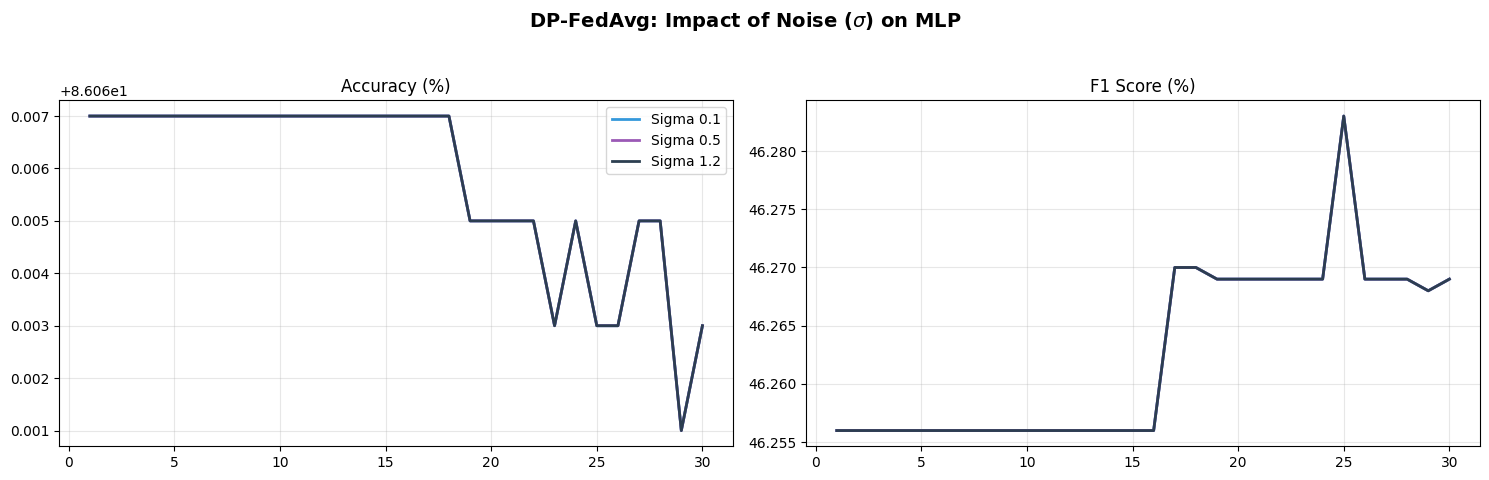

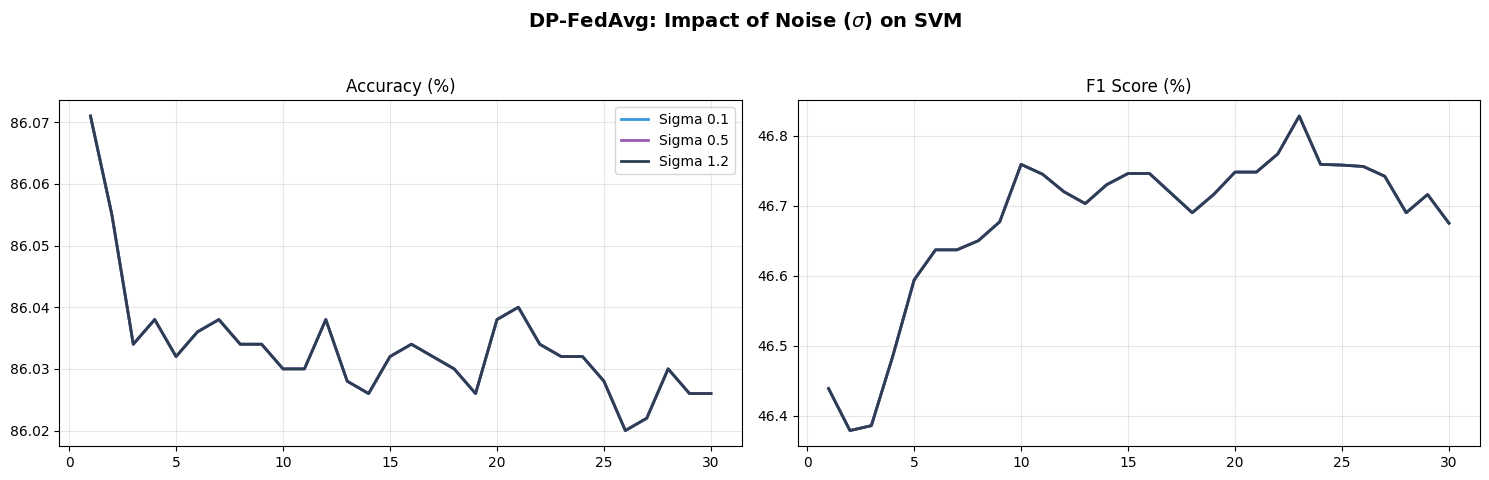

In [ ]:
def plot_utility_noise(base_path, sigmas, models):
    plots = [('accuracy', 'Accuracy (%)'), ('macro_f1', 'F1 Score (%)')]

    for m_name in models:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle(f'DP-FedAvg: Impact of Noise ($\sigma$) on {m_name}', fontsize=14, fontweight='bold')
        
        for sigma in sigmas:
            model_run_path = base_path / str(sigma) / m_name
            try:
                df = load_global_metrics(model_run_path)
                for i, (col, title) in enumerate(plots):
                    actual_col = col if col in df.columns else f'test_{col}'
                    if actual_col in df.columns:
                        axes[i].plot(df['round'], df[actual_col] * 100, 
                                     label=f'Sigma {sigma}', color=COLORS[str(sigma)], lw=2)
                        axes[i].set_title(title)
                        axes[i].grid(True, alpha=0.3)
            except Exception as e:
                print(f"Erreur pour {m_name} Sigma {sigma}: {e}")
        
        axes[0].legend()
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

plot_utility_noise(BASE_PATH, SIGMAS, MODELS)

We can see that the curves overlap for all noise levels. Experience shows that there is a tipping point for privacy. <br>
Here, $\sigma=0.1$ is not a "small" amount of noise but it is already too much noise for the complexity of the task.”

We also notice that the F1 score drops to 46%, so models struggle to learn with noised data. 

The failure of the models in the DP-FedAvg scenario stems from a conflict between differential privacy and class imbalance. Random noise acts as a filter that masks the already rare features of the minority class (diabetic patients). Overwhelmed by this noise, the model is unable to extract a discriminating signal and ultimately defaults to systematically predicting the majority class.

### Confusion matrix

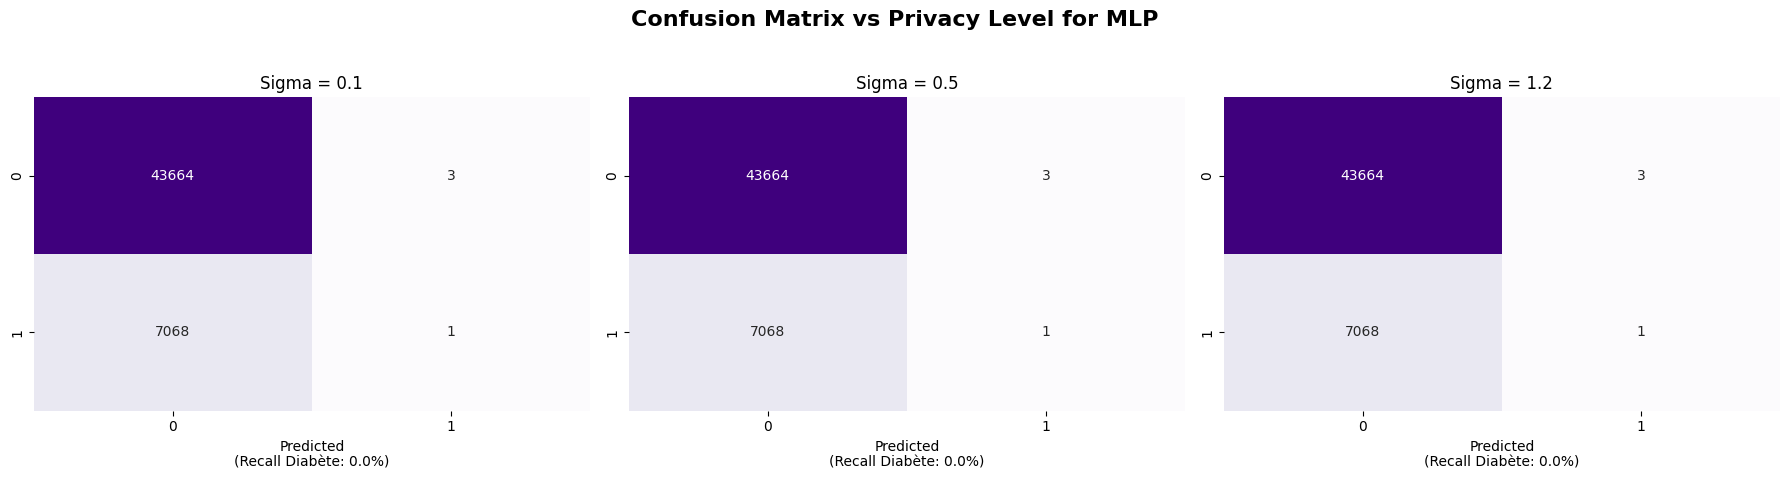

In [ ]:
def plot_confusion_noise_comparison(base_path, model_name, data):
    X_test, y_test = data.test
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Confusion Matrix vs Privacy Level for {model_name}', fontsize=16, fontweight='bold')
    
    model_classes = {'LR': Diabetes_LR, 'MLP': Diabetes_MLP, 'SVM': Diabetes_SVM}

    for i, sigma in enumerate(SIGMAS):
        model_folder = base_path / str(sigma) / model_name
        pth_file = next(model_folder.rglob("final_model.pth"), None)
        
        if pth_file:
            model = model_classes[model_name](input_dim=21)
            
            # --- CORRECTION DU CHARGEMENT ---
            state_dict = torch.load(pth_file, map_location='cpu')
            
            # On crée un nouveau state_dict en enlevant le préfixe '_module.'
            new_state_dict = {}
            for k, v in state_dict.items():
                name = k.replace("_module.", "") # Supprime le préfixe si présent
                new_state_dict[name] = v
            
            model.load_state_dict(new_state_dict)
            # -------------------------------
            
            model.eval()
            with torch.no_grad():
                preds = torch.argmax(model(X_test), dim=1)
            
            cm = confusion_matrix(y_test, preds)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[i], cbar=False)
            axes[i].set_title(f'Sigma = {sigma}')
            
            recall_1 = cm[1,1] / (cm[1,0] + cm[1,1]) * 100 if (cm[1,0] + cm[1,1]) > 0 else 0
            axes[i].set_xlabel(f'Predicted\n(Recall Diabète: {recall_1:.1f}%)')
            
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_confusion_noise_comparison(BASE_PATH, 'MLP', data_container)

Due to the crash of the models, these metrics are not really useful.

### Cost metrics

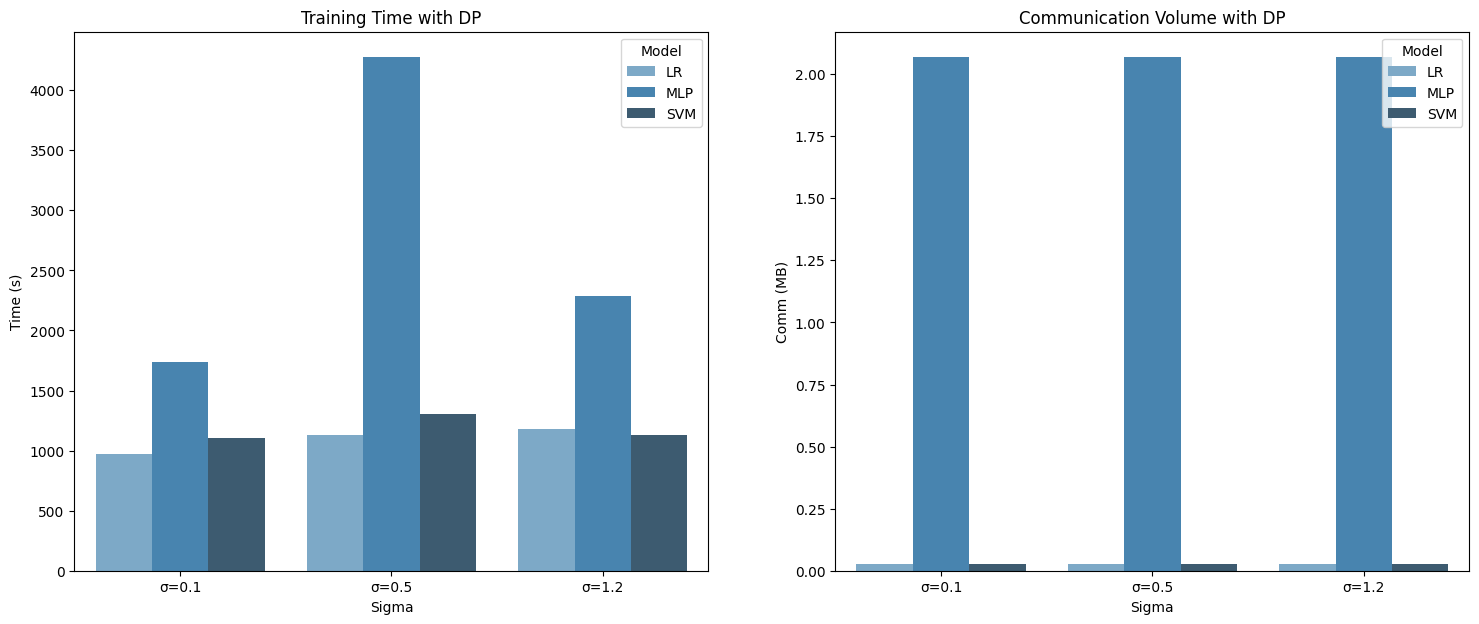

In [ ]:
def plot_costs_noise_comparison(base_path, sigmas, models):
    cost_data = []
    for sigma in sigmas:
        for m in models:
            run_path = base_path / str(sigma) / m
            t = load_run_time(run_path)
            df_c = load_comm_costs(run_path)
            c = df_c['comm_costs'].sum() / (1024**2) if df_c is not None else 0
            if t is not None:
                cost_data.append({'Sigma': f'σ={sigma}', 'Model': m, 'Time (s)': t, 'Comm (MB)': c})

    df_cost = pd.DataFrame(cost_data)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    sns.barplot(data=df_cost, x='Sigma', y='Time (s)', hue='Model', ax=ax1, palette='Blues_d')
    ax1.set_title('Training Time with DP')
    
    sns.barplot(data=df_cost, x='Sigma', y='Comm (MB)', hue='Model', ax=ax2, palette='Blues_d')
    ax2.set_title('Communication Volume with DP')
    
    plt.show()

plot_costs_noise_comparison(BASE_PATH, SIGMAS, MODELS)

MLP is a way more longer to train when we add some noise.

### Fairness metrics

[SyntaxWarning] <>:67
invalid escape sequence '\s'
[SyntaxWarning] <>:67
invalid escape sequence '\s'
[SyntaxWarning] C:\Users\bapti\AppData\Local\Temp\ipykernel_2636\1660617792.py:67
invalid escape sequence '\s'


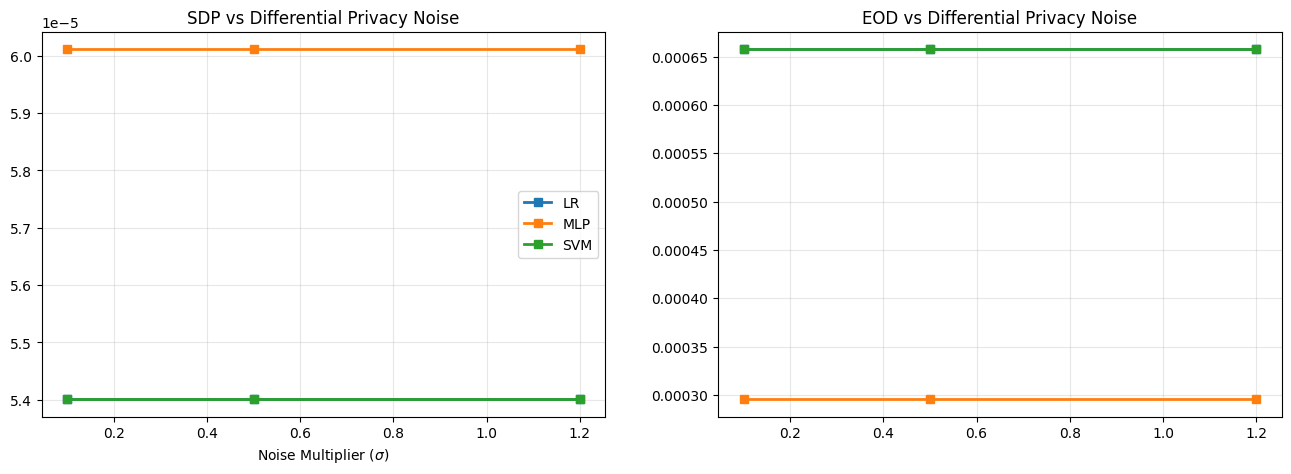

In [ ]:
def compute_fairness_for_all(paths, data_container, sex_index=17):
    X_test, y_test = data_container.test
    results = {}
    
    model_classes = {'LR': Diabetes_LR, 'MLP': Diabetes_MLP, 'SVM': Diabetes_SVM}
    
    # Masques de groupes (Sex: 1 vs 0)
    g1_mask = (X_test[:, sex_index] > 0)
    g0_mask = (X_test[:, sex_index] <= 0)
    mask_y1 = (y_test == 1)

    def get_rate(predictions, mask):
        return predictions[mask].float().mean().item() if mask.any() else 0.0

    for name, path in paths.items():
        model_file = path / 'final_model.pth'
        if not model_file.exists() or name not in model_classes:
            continue

        # 1. Instancier le modèle
        model = model_classes[name](input_dim=21)
        
        # 2. Charger et nettoyer le state_dict (Gestion du préfixe DP '_module.')
        state_dict = torch.load(model_file, map_location='cpu')
        new_state_dict = {k.replace("_module.", ""): v for k, v in state_dict.items()}
        
        model.load_state_dict(new_state_dict)
        model.eval()

        # 3. Prédictions
        with torch.no_grad():
            preds = torch.argmax(model(X_test), dim=1)

        # Calcul SDP : |P(pred=1|G=1) - P(pred=1|G=0)|
        sdp = abs(get_rate(preds, g1_mask) - get_rate(preds, g0_mask))

        # Calcul EOD : |P(pred=1|G=1, y=1) - P(pred=1|G=0, y=1)|
        eod = abs(get_rate(preds, g1_mask & mask_y1) - get_rate(preds, g0_mask & mask_y1))

        results[name] = {'SDP': sdp, 'EOD': eod}
    
    return results


def plot_fairness_noise_evolution(base_path, sigmas, models, data):
    fairness_stats = []
    
    for sigma in sigmas:
        paths_sigma = {}
        for m in models:
            model_file = next((base_path / str(sigma) / m).rglob("final_model.pth"), None)
            if model_file: paths_sigma[m] = model_file.parent
            
        res = compute_fairness_for_all(paths_sigma, data)
        for m_name, metrics in res.items():
            fairness_stats.append({'Sigma': float(sigma), 'Model': m_name, **metrics})

    df_fair = pd.DataFrame(fairness_stats)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    for m in models:
        subset = df_fair[df_fair['Model'] == m].sort_values('Sigma')
        ax1.plot(subset['Sigma'], subset['SDP'], marker='s', label=m, lw=2)
        ax2.plot(subset['Sigma'], subset['EOD'], marker='s', label=m, lw=2)
    
    ax1.set_title('SDP vs Differential Privacy Noise')
    ax2.set_title('EOD vs Differential Privacy Noise')
    ax1.set_xlabel('Noise Multiplier ($\sigma$)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax2.grid(True, alpha=0.3)
    plt.show()

plot_fairness_noise_evolution(BASE_PATH, SIGMAS, MODELS, data_container)

Due to the crash of the models, these metrics are not really useful.